<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Air_Pollution_PM2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

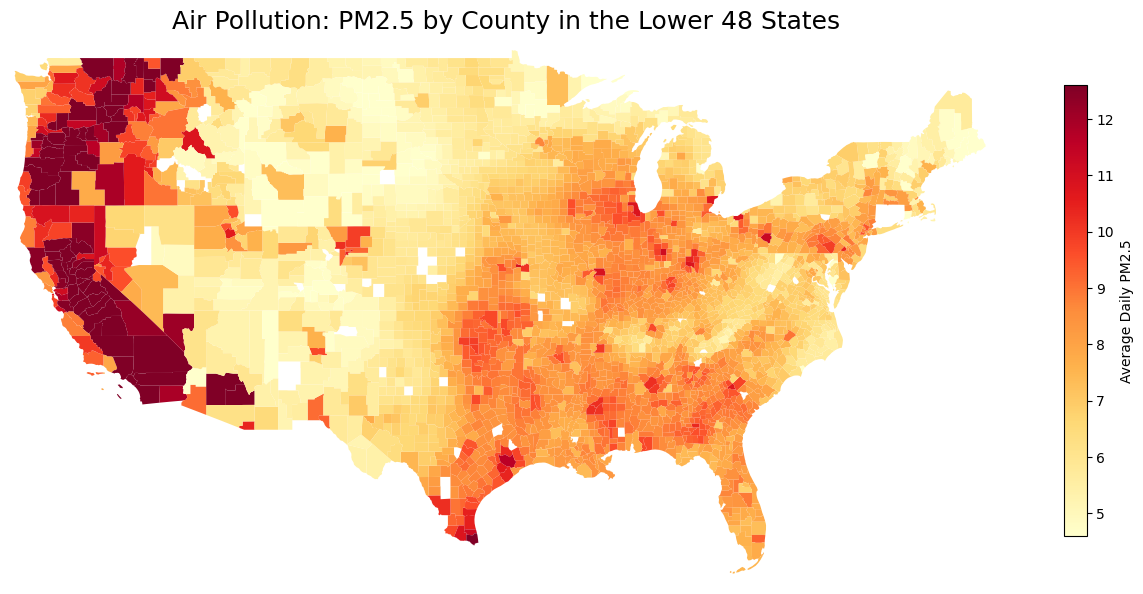

In [4]:
# Run once
# ! pip install numpy geopandas pandas matplotlib

import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

file = "/content/2025 County Health Rankings Data - v4.xlsx"

excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)
air_pollution = excel_data[[
    "FIPS",
    "State",
    "County",
    "Average Daily PM2.5" ]].copy()
# Keep only county rows
air_pollution = air_pollution[air_pollution["County"].notna()].copy()

# Some values are missing -> removes all values that missing
air_pollution = air_pollution[air_pollution["Average Daily PM2.5"].notna()].copy()

air_pollution["FIPS"] = (air_pollution["FIPS"].astype(int).astype(str).str.zfill(5))

counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

# Make sure coordinates are latitude/longitude
counties = counties.to_crs(epsg=4326)

# Merge air pollution data with county map
merged = counties.merge(
    air_pollution,
    left_on="GEOID",
    right_on="FIPS",
    how="inner"
)

lower48 = merged.cx[-125:-66, 24:50].copy()

# Remove Alaska, Hawaii, and territories by state name too
remove_states = [
    "Alaska",
    "Hawaii",
    "Puerto Rico",
    "Guam",
    "American Samoa",
    "Northern Mariana Islands",
    "Virgin Islands"
]

lower48 = lower48[~lower48["State"].isin(remove_states)].copy()

# Plot map using PM2.5 air pollution
vmin = lower48["Average Daily PM2.5"].quantile(0.02)
vmax = lower48["Average Daily PM2.5"].quantile(0.98)

fig, ax = plt.subplots(figsize=(16, 9))

lower48.plot(
    column="Average Daily PM2.5",
    cmap="YlOrRd",
    legend=True,
    edgecolor="none",
    linewidth=0,
    vmin=vmin,
    vmax=vmax,
    ax=ax,
    legend_kwds={
        "label": "Average Daily PM2.5",
        "shrink": 0.65
    }
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title("Air Pollution: PM2.5 by County in the Lower 48 States", fontsize=18)
ax.axis("off")

plt.show()